# Import

In [33]:
# Standard library imports
import os
import json

# Data manipulation and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Image processing
from PIL import Image
import cv2
import matplotlib.image as mpimg  # For loading images

# Machine learning libraries
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# TensorFlow and Keras
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [34]:
def create_dummy_image():
    dummy_image_path = "nosample.png" 
    if os.path.exists(dummy_image_path):
        return mpimg.imread(dummy_image_path)
    else:
        print(f"Warning: '{dummy_image_path}' not found. Using a blank dummy image.")
        return np.ones((100, 100, 3), dtype=np.uint8) * 255


# Load

In [9]:
# Define the directory containing the labeled dataset
directory = r'C:\Users\david\Desktop\project\dataset\Labeled'

# Initialize an empty list to store data
data = []

# Iterate through all files in the directory
for file in os.listdir(directory):
    if file.lower().endswith('.jpg'):
        image_path = os.path.join(directory, file)
        json_path = image_path.replace('.jpg', '.json')
        
        label = None
        if os.path.exists(json_path):
            try:
                with open(json_path, 'r') as f:
                    content = json.load(f)
                    shapes = content.get('shapes', [])
                    if shapes and isinstance(shapes, list):
                        label = shapes[0].get('label')
            except Exception as e:
                print(f"Error reading {json_path}: {e}")
        
        data.append({'filename': image_path, 'label': label})

df = pd.DataFrame(data)
print(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 428 entries, 0 to 427
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  428 non-null    object
 1   label     428 non-null    object
dtypes: object(2)
memory usage: 6.8+ KB
None


,filename,label
0,C:\Users\david\Desktop\project\dataset\Labeled...,no_good
1,C:\Users\david\Desktop\project\dataset\Labeled...,no_good
2,C:\Users\david\Desktop\project\dataset\Labeled...,no_good
3,C:\Users\david\Desktop\project\dataset\Labeled...,no_good
4,C:\Users\david\Desktop\project\dataset\Labeled...,good


# EDA

In [10]:
df.label.value_counts()

label
good           162
no_good        116
exc_solder      81
spike           38
poor_solder     31
Name: count, dtype: int64

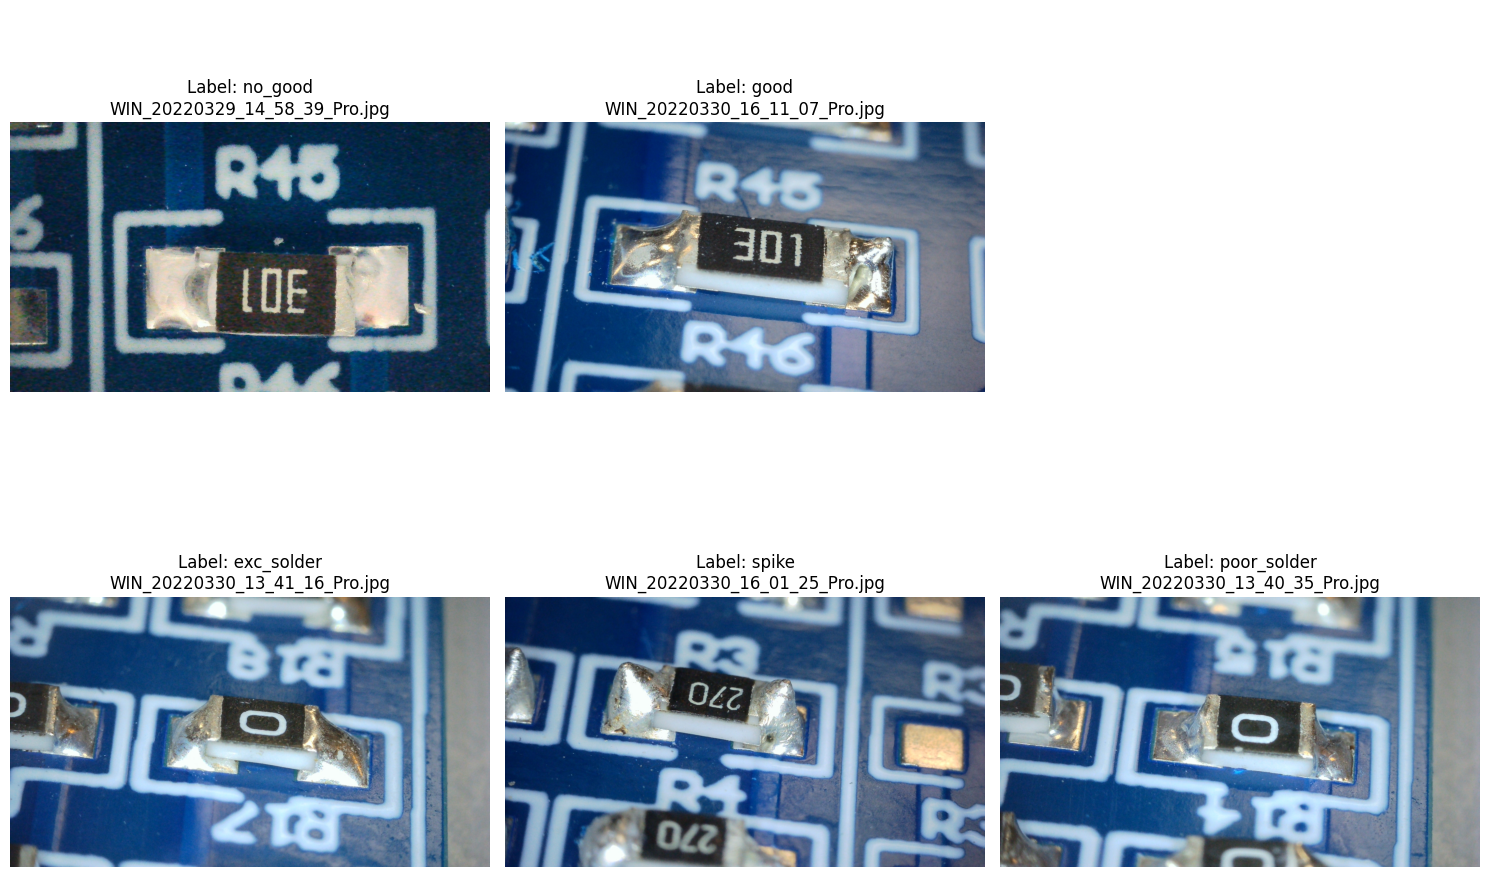

In [11]:
# Define subplot mapping for labels
subplot_mapping = {
    "no_good": (0, 0),
    "good": (0, 1),
    "exc_solder": (1, 0),
    "spike": (1, 1),
    "poor_solder": (1, 2)
}

# Create a 2x3 grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Iterate through each label and its subplot position
for label, (row, col) in subplot_mapping.items():
    ax = axes[row, col]
    group = df[df['label'] == label]
    
    if not group.empty:
        # Sample one image from the group
        sample = group.sample(n=1).iloc[0]
        image_path = sample['filename']
        
        try:
            # Load and display the image
            image = Image.open(image_path)
            ax.imshow(image)
        except Exception as e:
            # Display error message if image loading fails
            ax.text(0.5, 0.5, f"Error loading image:\n{e}", ha='center', va='center')
    else:
        # Display message if no image is found for the label
        ax.text(0.5, 0.5, "No image found", ha='center', va='center')
    
    # Set title and turn off axis
    ax.set_title(f"Label: {label}\n{os.path.basename(sample['filename']) if not group.empty else ''}")
    ax.axis('off')

# Turn off unused subplot axes if there are fewer than 6 unique labels
used_positions = set(subplot_mapping.values())
for r in range(2):
    for c in range(3):
        if (r, c) not in used_positions:
            axes[r, c].axis('off')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

# preprocessing and augmentation

In [94]:
# Preprocessing
df_filtered = df[~df['label'].isin(['good', 'no_good'])].copy()
target_size = (224, 224)
batch_size = 32

train_df, val_df = train_test_split(
    df_filtered, test_size=0.2, stratify=df_filtered['label'], random_state=42
)

train_datagen = ImageDataGenerator(rescale=1.0/255)
val_datagen = ImageDataGenerator(rescale=1.0/255)

# Augmentation
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='filename',
    y_col='label',
    target_size=target_size,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=True
)

val_generator = val_datagen.flow_from_dataframe(
    val_df,
    x_col='filename',
    y_col='label',
    target_size=target_size,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False
)


Found 120 validated image filenames belonging to 3 classes.
Found 30 validated image filenames belonging to 3 classes.


In [95]:
import albumentations as A
from albumentations.pytorch.transforms import ToTensorV2
import cv2

# Define class indices manually
class_indices = {label: idx for idx, label in enumerate(train_df['label'].unique())}

# Define Albumentations augmentation pipeline
augmentation_pipeline = A.Compose([
    A.Resize(target_size[0], target_size[1]),
    A.HorizontalFlip(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# Custom data generator using Albumentations
def albumentations_data_generator(df, batch_size, augmentations, target_size):
    while True:
        for i in range(0, len(df), batch_size):
            batch_df = df.iloc[i:i+batch_size]
            images = []
            labels = []
            for _, row in batch_df.iterrows():
                # Read image
                image = cv2.imread(row['filename'])
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
                
                # Apply augmentations
                augmented = augmentations(image=image)
                image = augmented['image']
                
                # Transpose image to channels-last format
                if image.shape[0] == 3:  # Check if the image is in channels-first format
                    image = np.transpose(image, (1, 2, 0))  # Convert to (height, width, channels)
                
                images.append(image)
                
                # Map string label to integer and one-hot encode
                label = class_indices[row['label']]  # Convert string label to integer
                labels.append(tf.keras.utils.to_categorical(label, num_classes=len(class_indices)))
            
            yield np.array(images), np.array(labels)

# Create generators
train_generator = albumentations_data_generator(train_df, batch_size, augmentation_pipeline, target_size)
val_generator = albumentations_data_generator(val_df, batch_size, augmentation_pipeline, target_size)



# CNN

In [97]:
model = models.Sequential([
    layers.Conv2D(16, (3, 3), activation='relu', input_shape=(target_size[0], target_size[1], 3)),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(32, (3, 3), activation='relu'), 
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'), 
    # layers.Dense(len(train_generator.class_indices), activation='softmax')
    layers.Dense(len(class_indices), activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# Calculate steps per epoch
steps_per_epoch = math.ceil(len(train_df) / batch_size)
validation_steps = math.ceil(len(val_df) / batch_size)

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,  # Specify steps per epoch
    epochs=10,
    validation_data=val_generator,
    validation_steps=validation_steps  # Specify validation steps
)

# Save the trained model
model.save("simple_classification_model.h5")


Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_47 (Conv2D)              │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_47 (MaxPooling2D) │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 109, 109, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_48 (MaxPooling2D) │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_20 (Flatten)            │ (None, 93312)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 64)             │     5,972,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,977,315 (22.80 MB)

 Trainable params: 5,977,315 (22.80 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.2790 - loss: 11.1550 - val_accuracy: 0.2667 - val_loss: 8.6360
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 745ms/step - accuracy: 0.2369 - loss: 7.3396 - val_accuracy: 0.3333 - val_loss: 1.5246
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.5770 - loss: 1.7217 - val_accuracy: 0.5333 - val_loss: 1.5086
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.5857 - loss: 1.1425 - val_accuracy: 0.5333 - val_loss: 1.2089
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.5767 - loss: 1.0426 - val_accuracy: 0.5333 - val_loss: 1.0532
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.5739 - loss: 0.9001 - val_accuracy: 0.5333 - val_loss: 0.9711
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.6438 - loss: 0.8251 - val_accuracy: 0.5333 - val_loss: 0.9778
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.6964 - loss: 0.7468 - val_accuracy: 0.5333 - val_loss: 0.9896
Epoch 9/10
4

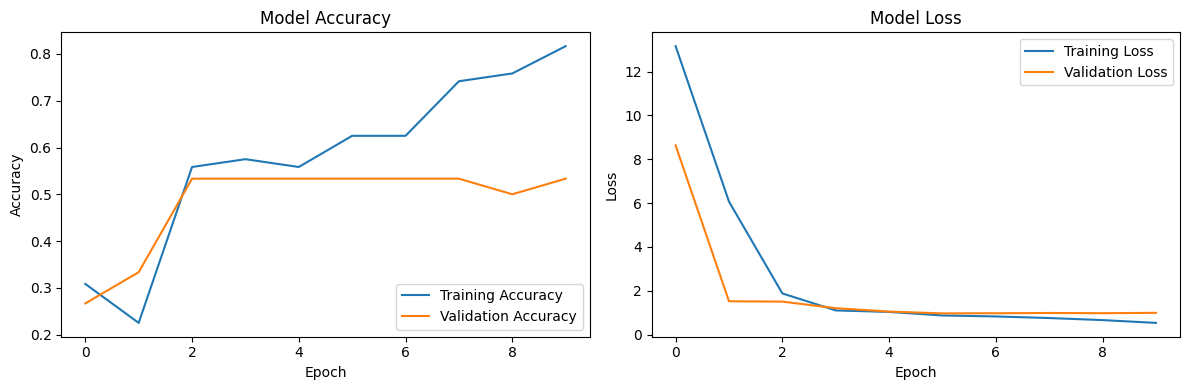

In [98]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

# Show the plots
plt.tight_layout()
plt.show()

# Evaluation

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
Classification Report:
               precision    recall  f1-score   support

  exc_solder       0.57      0.75      0.65        16
       spike       0.50      0.50      0.50         8
 poor_solder       1.00      0.17      0.29         6

    accuracy                           0.57        30
   macro avg       0.69      0.47      0.48        30
weighted avg       0.64      0.57      0.54        30



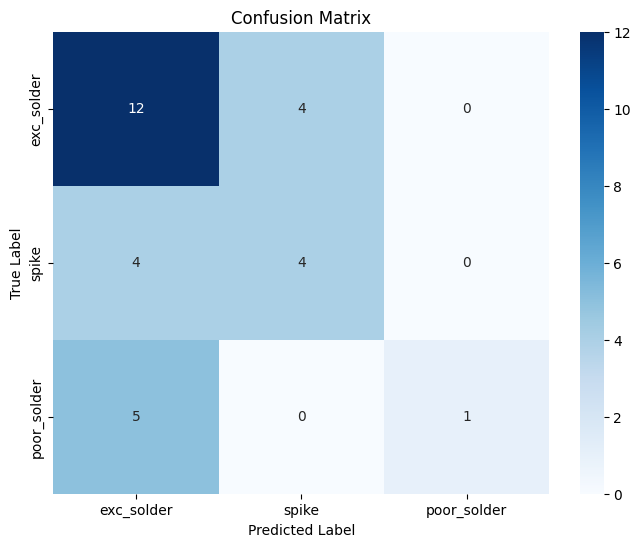

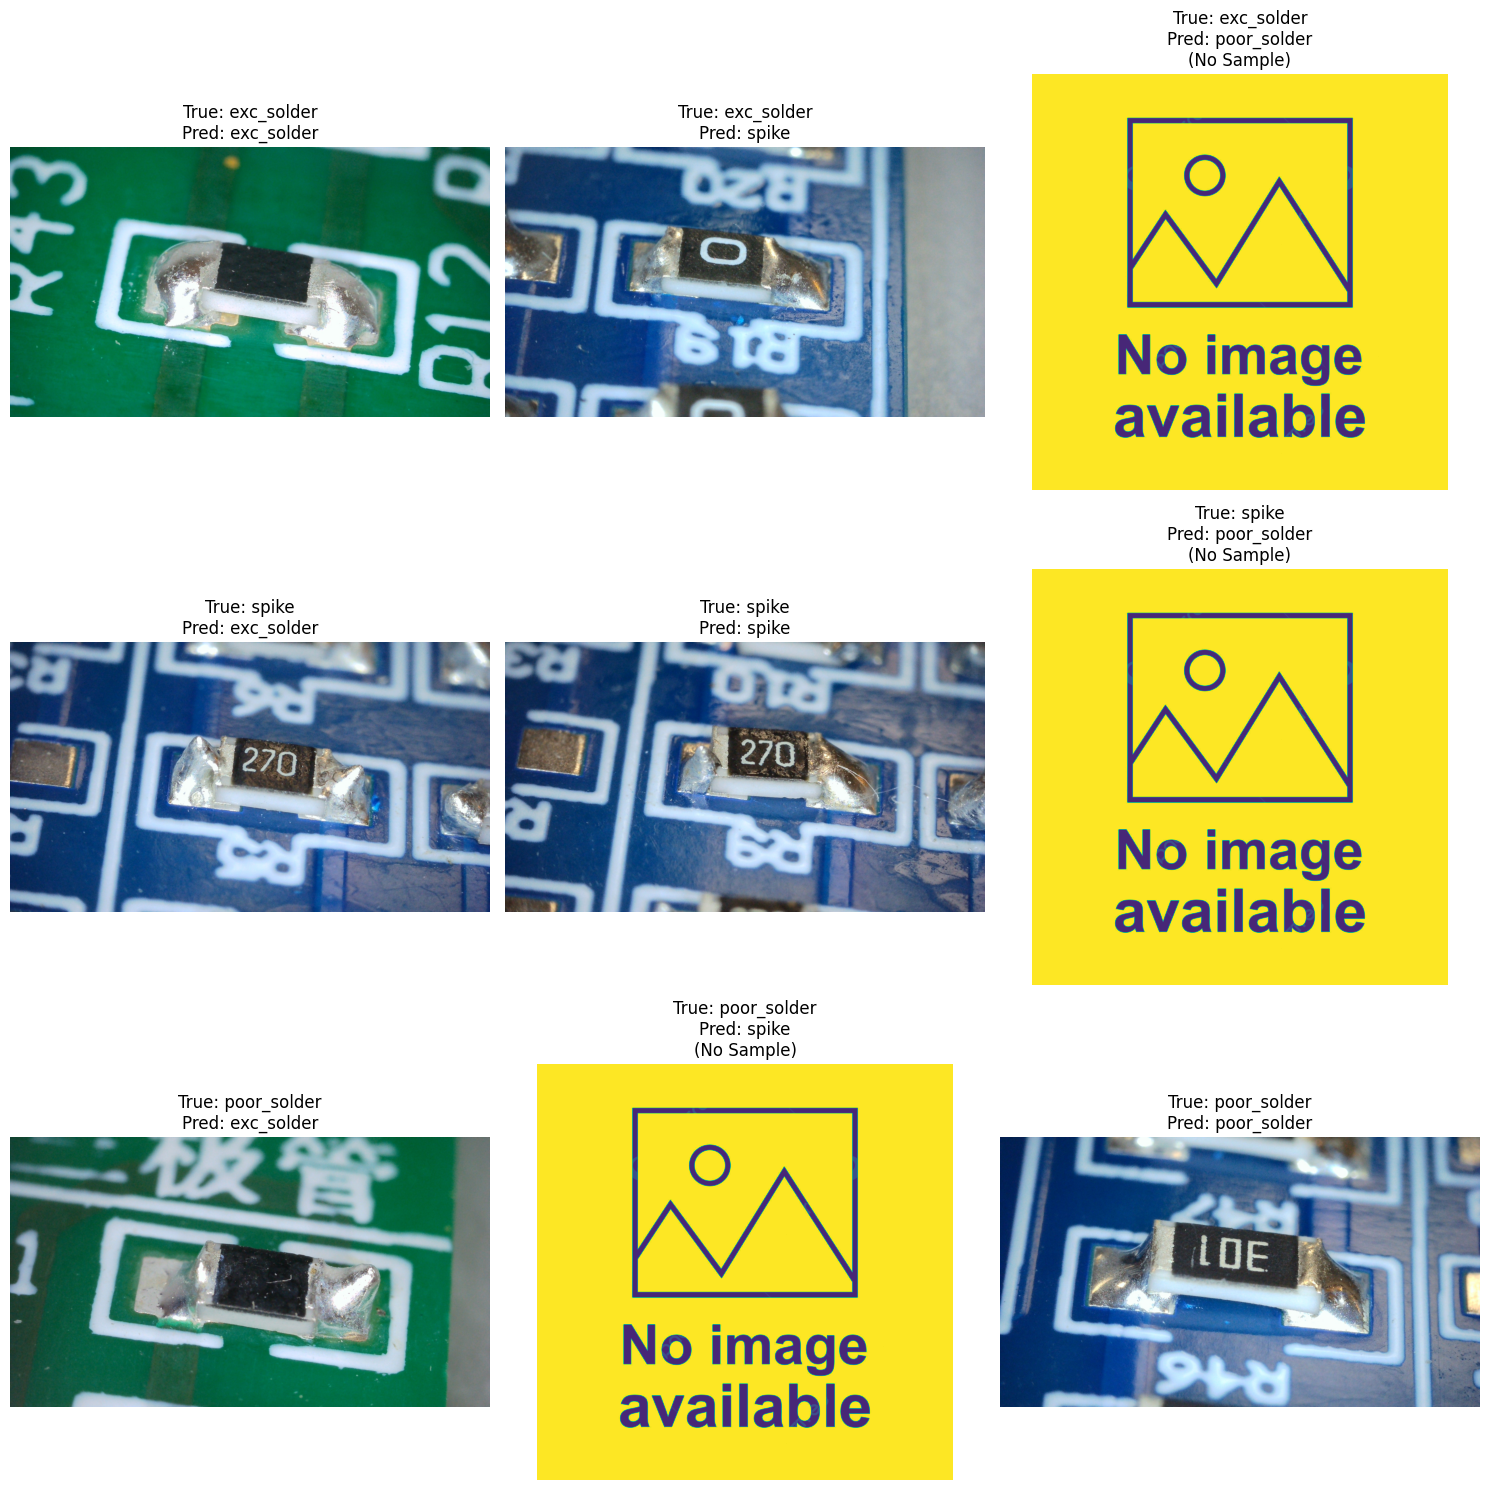

In [99]:
# Predict
val_steps = math.ceil(len(val_df) / batch_size)  # Calculate validation steps
predictions = model.predict(val_generator, steps=val_steps)
predicted_classes = np.argmax(predictions, axis=1)

# Ground truth labels
true_classes = val_df['label'].map(class_indices).values  # Map string labels to integers
class_labels = list(class_indices.keys())

# Classification report
report = classification_report(true_classes, predicted_classes, target_names=class_labels)
print("Classification Report:\n", report)

# Confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Error analysis: Sample one image from each confusion matrix cell
plt.figure(figsize=(15, 15))
num_classes = len(class_labels)

# Track the number of subplots dynamically
subplot_count = 0

for true_label in range(num_classes):
    for predicted_label in range(num_classes):
        # Find indices of samples for the current true and predicted label pair
        indices = np.where((true_classes == true_label) & (predicted_classes == predicted_label))[0]
        
        if len(indices) > 0:
            # Sample one image from the indices
            idx = indices[0]  # Take the first one (or random.choice(indices) for randomness)
            image_path = val_df['filename'].iloc[idx]

            # Load the image
            if os.path.exists(image_path):
                image = plt.imread(image_path)
            else:
                image = create_dummy_image()
        else:
            # Use a placeholder image if no sample exists for this cell
            image = create_dummy_image()
        
        # Display the image
        subplot_count += 1
        plt.subplot(num_classes, num_classes, subplot_count)
        plt.imshow(image)
        title = f"True: {class_labels[true_label]}\nPred: {class_labels[predicted_label]}"
        if len(indices) == 0:
            title += "\n(No Sample)"
        plt.title(title)
        plt.axis('off')

# Adjust layout and display the plot
if subplot_count > 0:
    plt.tight_layout()
    plt.show()
else:
    print("No misclassifications to display.")